# More images!

## Make images

In [1]:
import radmc3d_tools
import radmc3dPy
import numpy as np

Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.


In [2]:
import os
# so it can find Radmc3D
os.environ["PATH"] += ":/home/hd/hd_hd/hd_cu284/bin"
# so it can find other libraries Radmc3D depends on that I cannot access from inside the singularity container.
# DO NOT TOUCH!!!!
os.environ["LD_LIBRARY_PATH"] = "/home/hd/hd_hd/hd_cu284/libs:" + os.environ.get("LD_LIBRARY_PATH", "")
# Change path to dir that contains all the radmc3d-relevant files, like dust_density.inp etc.
os.chdir("/home/hd/hd_hd/hd_cu284/jupyter notebooks/thesis_suited_plots_maybe/radmc3d_sims")
# Don't touch. 

###### REMEMBER TO CHECK PATH ########

## Creating the dust_temp.dat file

In [3]:
## instead of running radmc3d mctherm (which takes a long time and is not relevant for our wavelength range) we define the 
## dust_temperature.dat file on our own.
path = "/home/hd/hd_hd/hd_cu284/jupyter notebooks/thesis_suited_plots_maybe/radmc3d_sims"
rho = np.fromfile(f"{path}/dust_density.inp", sep="\n")  # adjust separator if needed
n_cells = len(rho)-3

# Create dust temperatures
dust_temp = np.ones(shape=n_cells)
dust_temp *= 10  # arbitrary temperature 10K

# Write to file in RADMC-3D format
with open(f"{path}/dust_temperature.dat", "w") as f:
    f.write("1\n")            # number of dust species
    f.write(f"{n_cells}\n")   # number of cells
    f.write("1\n")            # number of components (usually 1)
    # Now write the temperatures in scientific notation
    for temp in dust_temp:
        f.write(f" {temp:.6e}\n")

In [4]:
dust_temp= np.fromfile(f"{path}/dust_temperature.dat", sep="\n ")
print(dust_temp)

[1.0000e+00 6.1056e+06 1.0000e+00 ... 1.0000e+01 1.0000e+01 1.0000e+01]


In [5]:
from radmc3dPy.image import makeImage, readImage, plotImage

In [6]:
import os
import sys

class silence_stdout_stderr:
    def __enter__(self):
        # Save original FDs
        self.old_stdout = os.dup(1)
        self.old_stderr = os.dup(2)

        # Redirect both to /dev/null
        self.devnull = os.open(os.devnull, os.O_WRONLY)
        os.dup2(self.devnull, 1)
        os.dup2(self.devnull, 2)

    def __exit__(self, *args):
        # Restore original FDs
        os.dup2(self.old_stdout, 1)
        os.dup2(self.old_stderr, 2)

        os.close(self.devnull)
        os.close(self.old_stdout)
        os.close(self.old_stderr)

# K-Band: 2.2µm, fiducial model, dens=1

From the article: We find an average inclination of 43°.99 ± 0°.87
and position angle of 358°.7 ± 1°.1 in the H band, and
45°.86 ± 1°.27 and 359°.3 ± 2°.3 in the Ks band, respectively

In [7]:
incl = 45.0
posang = 356.+90
npix = 50
sizeau = 400.
phi= 70 # does not do that much
wav_K = 2.2 # K band
wav_H = 1.65 # H band

In [8]:
import subprocess
import os
from radmc3dPy.image import makeImage

# Save original environment
with silence_stdout_stderr():
    makeImage(npix=npix, incl=incl, wav=wav_K, sizeau=sizeau, phi=phi, posang=posang,
              pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)

image_K0 = readImage()

Executing RADMC-3D Command:
radmc3d image npix 50 incl 45.0 sizeau 400.0 lambda 2.2 phi 70 posang 446.0 pointau 0.0 0.0 0.0 fluxcons nostar


KeyboardInterrupt: 

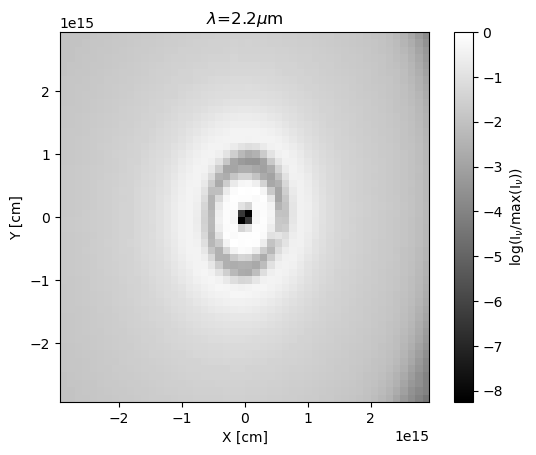

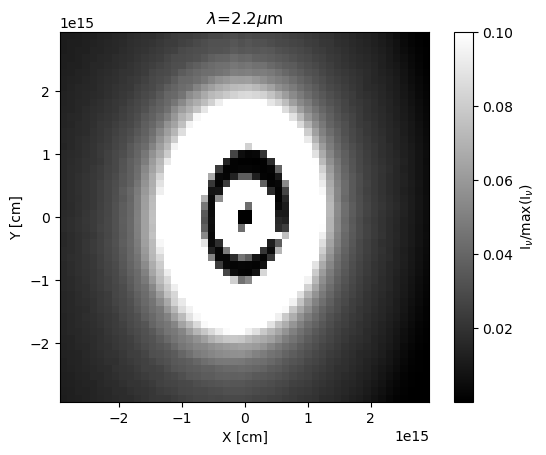

{'implot': <matplotlib.image.AxesImage at 0x14bbca1195b0>,
 'cbar': <matplotlib.colorbar.Colorbar at 0x14bbca118920>}

In [26]:
plotImage(image_K0,log=True, maxlog=10)#saturate=0.1)#
plotImage(image_K0,saturate=0.1)

# H-Band: 1.65µm

In [ ]:
import subprocess
import os
from radmc3dPy.image import makeImage

# Save original environment
with open(os.devnull, "w") as fnull:
    subprocess.run = lambda *a, **kw: __import__('subprocess').run(*a, stdout=fnull, stderr=fnull, **kw)
    
    makeImage(npix=150, incl=0.0, wav=1.65, sizeau=300., phi=0., posang=15.,
              pointau=[0., 0., 0.], fluxcons=True, nostar=False, noscat=False)

    image_H0 = readImage()

In [ ]:

plotImage(image_H0, log=True, maxlog=20)

# Images for all models

Maybe add an exponential cutoff at the edge?

In [9]:
incl = 45.0
posang = 356.+90
npix = 200
sizeau = 400.
phi= 70 # does not do that much
wav_K = 2.2 # K band
wav_H = 1.65 # H band

In [10]:
path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
path_endings=["fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              "fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen", ]
sigslopes = np.array([1,1,1,1,1,0,0.5,-2])



paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])


In [11]:
dens_list = np.ones(len(path_endings))*0.05

#### Or, if same disk mass and not same sigma_0 at planet desired
#dens_list=0.1*ms/(57**2*(r_max**(2-sigslopes)-r_min**(2-sigslopes))/(2-sigslopes)*57**sigslop*au**2*sigma_0*2*np.pi #g/cm²)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0) # g/cm²

for it,sigslop in enumerate(sigslopes):
    M = dens_list[it]*57**2*(r_max**(2-sigslop)-r_min**(2-sigslop))/(2-sigslop)*57**sigslop*au**2*sigma_0*2*np.pi #g/cm²
    print(f"##### {path_endings[it]} #####")
    print(f"Estimate for disk mass: {M/ms} solar masses")




##### fargo_fiducial_2gen #####
Estimate for disk mass: 0.08249040000031344 solar masses
##### fargo_high_mass_2gen #####
Estimate for disk mass: 0.08249040000031344 solar masses
##### fargo_low_mass_2gen #####
Estimate for disk mass: 0.08249040000031344 solar masses
##### fargo_high_visc_2gen #####
Estimate for disk mass: 0.08249040000031344 solar masses
##### fargo_low_visc_2gen #####
Estimate for disk mass: 0.08249040000031344 solar masses
##### fargo_sigslop_0_2gen #####
Estimate for disk mass: 0.00528228000002007 solar masses
##### fargo_sigslop_0.5_2gen #####
Estimate for disk mass: 0.019956142958530425 solar masses
##### fargo_sigslop_-2_2gen #####
Estimate for disk mass: 3.990568254862808e-05 solar masses


In [ ]:
from altered_setup import main
import subprocess
import os
from radmc3dPy.image import makeImage, readImage, plotImage

images_K=[]
images_H=[]
sigmeans = []


for i,path in enumerate(paths):
    sigma_dust_2d = main(path, dens=dens_list[i])
    print(f"Image {i+1} of {len(paths)}")
    with silence_stdout_stderr():
        makeImage(npix=npix, incl=incl, wav=wav_K, sizeau=sizeau, phi=phi, posang=posang,
                  pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)
    
    image = readImage()
    images_K.append(image)

    """
    with silence_stdout_stderr():
        makeImage(npix=npix, incl=incl, wav=wavH, sizeau=sizeau, phi=phi, posang=posang,
                  pointau=[0., 0., 0.], fluxcons=True, nostar=True, noscat=False)
    
    image = readImage()
    images_H.append(image)
    """    
    sigma_mean = np.mean(sigma_dust_2d[0], axis=1)
    sigmeans.append(sigma_mean)

    np.save("images_K",images_K, allow_pickle=True)
    np.save("images_H",images_H, allow_pickle=True)
    np.save("sigmameans",sigmeans, allow_pickle=True)
    np.save("dens", dens_list, allow_pickle=True)

1 dust species detected!
Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.06912608418792082
  FlaringIndex in RADMC-3D model at R0 = 0.24934156881001246
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RADMC-3D model, or the parameters
in the FARGO3D model, to make them both mutually self-consistent.
Reading dustkapscatmat_1.00e-01.inp
Image 1 of 8
Executing RADMC-3D Command:
radmc3d image npix 200 incl 45.0 sizeau 400.0 lambda 2.2 phi 70 posang 446.0 pointau 0.0 0.0 0.0 fluxcons nostar


In [42]:
import numpy as np
from radmc3dPy.image import makeImage, plotImage
images_K = np.load("images_K.npy", allow_pickle=True)
images_H = np.load("images_H.npy", allow_pickle=True)
sigmeans = np.load("sigmameans.npy", allow_pickle=True)
dens_list = np.load("dens.npy", allow_pickle=True)

In [ ]:
r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]

for i,path in enumerate(paths):
    plt.plot(r_list*57, sigmeans[i], label=f"{path[43:-5]}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("r [au]")
plt.ylabel("$\\Sigma_{dust}$ [g/cm²]")
plt.title("Dust density")

In [ ]:
for i,path in enumerate(paths):
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    plotImage(images_K[i],log=True, maxlog=10)#saturate=0.1)#
    plotImage(images_K[i],saturate=0.005)

In [ ]:
for i,path in enumerate(paths):
    print(f"#########################\n{path[43:-5]} images:#########################")
    plotImage(images_H[i],log=True, maxlog=10)#saturate=0.1)#
    plotImage(images_H[i],saturate=0.005)

In [ ]:

index_for_mass=[1,0,2]

for i in index_for_mass:
    path = paths[i]
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    #plotImage(images_K[i],log=True, maxlog=10)#saturate=0.1)#
    plotImage(images_K[i],saturate=0.01)

for i in index_for_mass:
    path = paths[i]
    plt.plot(r_list,sigmeans[i], label=f"{path[43:-5]}")

plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma_{dust}$ [g/cm²]")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.title("Different masses")

### Notes planet mass
- lower planet mass -> shallower, narrower gap
- higher planet mass -> deeper gap, but only to some point
- higher planet mass -> Rossby wave very visible!
- in all images spirals somewhat visible

In [ ]:
index_for_visc=[3,0,4]

for i in index_for_visc:
    path = paths[i]
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    #plotImage(images_K[i],log=True, maxlog=10)#saturate=0.1)#
    plotImage(images_K[i],saturate=0.005)

for i in index_for_visc:
    path = paths[i]
    plt.plot(r_list,sigmeans[i], label=f"{path[43:-5]}")

plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma_{dust}$ [g/cm²]")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.title("Different viscosities")

### Notes viscosity
- higher viscosity -> shallower gap
- lower viscosity -> deeper gap, but only to some point
- higher viscosity -> spirals more visible, apparently??
- lower viscosity -> Rossby wave (?), outer edge of gap slightly egg-shaped

In [ ]:
index_for_sigslop = [0,6,5,7]
saturate_list = [0.01,0.01,0.01,0.05]#np.ones(4)

for it,i in enumerate(index_for_sigslop):
    path = paths[i]
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    #plotImage(images_K[i],log=True, maxlog=10)#saturate=0.1)#
    plotImage(images_K[i],saturate=saturate_list[it])

for i in index_for_sigslop:
    path = paths[i]
    plt.plot(r_list,sigmeans[i], label=f"{path[43:-5]}")

plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma_{dust}$ [g/cm²]")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.title("Different sigma slopes")

### Notes sigma slope
- for (very weird) sigma slope of -2, back of disk is visible at the edge. Also, disk scatters much better at large r.
- gap depth does (weakly!) depend on sigma slope
- 